# Exploratory Data Analysis

This notebook explores the master weekly dataset assembled in `data_cleaning.ipynb`. It covers time-series visualization of market volatility and health signals, correlation analysis (full period, pre-COVID, flu-season, and three-period breakdowns), statistical assumption tests (normality, multicollinearity, autocorrelation), lag analysis to test whether health signals lead market volatility, rolling correlation to detect regime changes, and volatility spike identification.

## Inspection & Validation

Confirm the master dataset loaded correctly and all 19 expected columns are present before beginning analysis.

In [1]:
import pandas as pd
temp = pd.read_csv('../data/processed/master_weekly.csv', index_col=0, parse_dates=True)
print(temp.columns.tolist())

['KIE', 'PJP', 'XBI', 'XLV', 'KIE_vol', 'PJP_vol', 'XBI_vol', 'XLV_vol', 'cpi', 'unemployment', 'interest_rate', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath', 'wili', 'ili', 'num_ili', 'num_patients', 'nchs_deaths']


All 19 expected columns are present: 4 ETF closing prices, 4 volatility measures, 3 FRED macro indicators, 3 Google Trends signals, 4 FluView ILI metrics, and NCHS annual deaths — checking that the cleaning notebook produced the expected output.

In [2]:
master_df = pd.read_csv('../data/processed/master_weekly.csv', index_col=0, parse_dates=True)
print(master_df.shape)
print(master_df.head())

(730, 19)
                 KIE        PJP        XBI        XLV   KIE_vol   PJP_vol  \
2010-01-10  9.057225  15.203443  17.865004  24.007961  0.008310  0.003637   
2010-01-17  9.049768  15.413590  17.691778  24.340349  0.009688  0.010255   
2010-01-24  8.721590  15.033717  17.666115  23.917307  0.018964  0.019509   
2010-01-31  8.768827  15.049875  17.733477  23.630234  0.011464  0.007055   
2010-02-07  8.656946  14.823567  17.617998  23.290281  0.022845  0.017174   

             XBI_vol   XLV_vol      cpi  unemployment  interest_rate  \
2010-01-10  0.005600  0.008326  217.488           9.8           0.11   
2010-01-17  0.013182  0.009302  217.488           9.8           0.11   
2010-01-24  0.016421  0.019749  217.488           9.8           0.11   
2010-01-31  0.010720  0.005938  217.488           9.8           0.11   
2010-02-07  0.027868  0.017661  217.281           9.8           0.13   

            trends_flu_symptoms  trends_fever  trends_shortness_of_breath  \
2010-01-10       

730 weekly observations from 2010-01-10 to 2023-12-31 with no unexpected gaps, matching the yfinance coverage confirmed in cleaning.

## Time Series Visualization

Plots each key variable over the full 14-year study window. The COVID period (2020-2021) is shaded red on each chart as a reference for the most significant health-market event in the dataset.

### Target: XLV Weekly Volatility

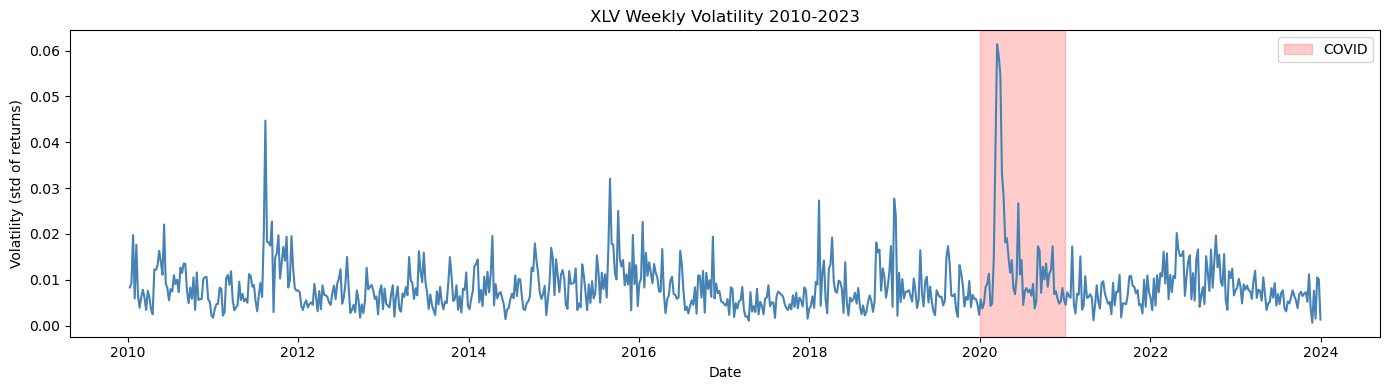

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(master_df.index, master_df['XLV_vol'], color='steelblue')
plt.title('XLV Weekly Volatility 2010-2023')
plt.xlabel('Date')
plt.ylabel('Volatility (std of returns)')
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.legend()
plt.tight_layout()
plt.show()

What it shows: A single line tracking how much XLV (the broad healthcare ETF) moved week to week over 14 years.
Interpretation: Not one massive spike — six distinct elevated periods stand out against an otherwise low, flat baseline: the August 2011 debt-ceiling crisis (~0.045), a 2015 cluster (~0.025–0.032), a January 2016 selloff (~0.023), the February and December 2018 volatility spikes (~0.027–0.028), a January 2019 spike (~0.024), and COVID in March 2020 (~0.061 — the largest in the dataset, but not by an overwhelming margin over the 2011 spike). The market has reacted to a range of shocks over 14 years, not just COVID.
Relevance: This is your target variable. Everything else in the project gets measured against this line. It proves the phenomenon you're studying is real and recurring — the question is whether any of these shocks, COVID included, can be seen coming from health-signal data.

### Sector Comparison: All ETF Volatilities

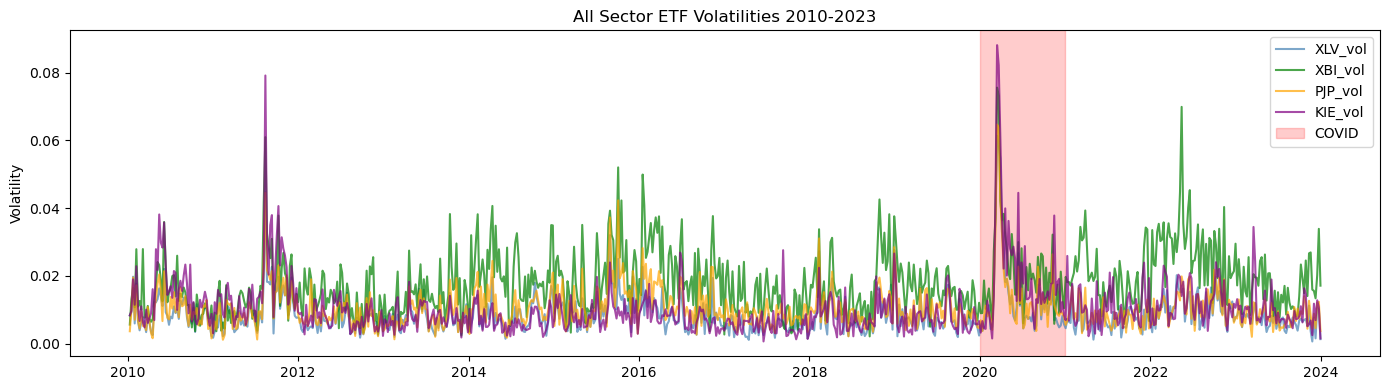

In [4]:
plt.figure(figsize=(14, 4))
for col, color in zip(['XLV_vol', 'XBI_vol', 'PJP_vol', 'KIE_vol'], ['steelblue', 'green', 'orange', 'purple']):
    plt.plot(master_df.index, master_df[col], label=col, color=color, alpha=0.7)
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.title('All Sector ETF Volatilities 2010-2023')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.savefig('plot2_all_vol.png', dpi=150)
plt.show()

What it shows: XLV, XBI, PJP, and KIE volatility on the same chart.
Interpretation: All four sectors spike together during COVID — they're correlated during extreme events. But in normal times they behave differently. XBI (biotech) is noisier throughout the full period, which makes sense since biotech is more speculative. XLV is the calmest, sitting at the lowest baseline nearly throughout. KIE (insurance) is not calm: its all-time high (~0.088) comes during COVID — taller than XLV's own COVID peak (~0.061) — and it has a nearly-as-large spike during the August 2011 debt-ceiling crisis (~0.079), the second-largest non-COVID spike in the entire dataset.
Relevance: Shows that the health-market relationship isn't sector-specific — it hits all four simultaneously during a real crisis. But the magnitude, and which sector is calmest, differs by sector.

### Health Signal: Weighted ILI

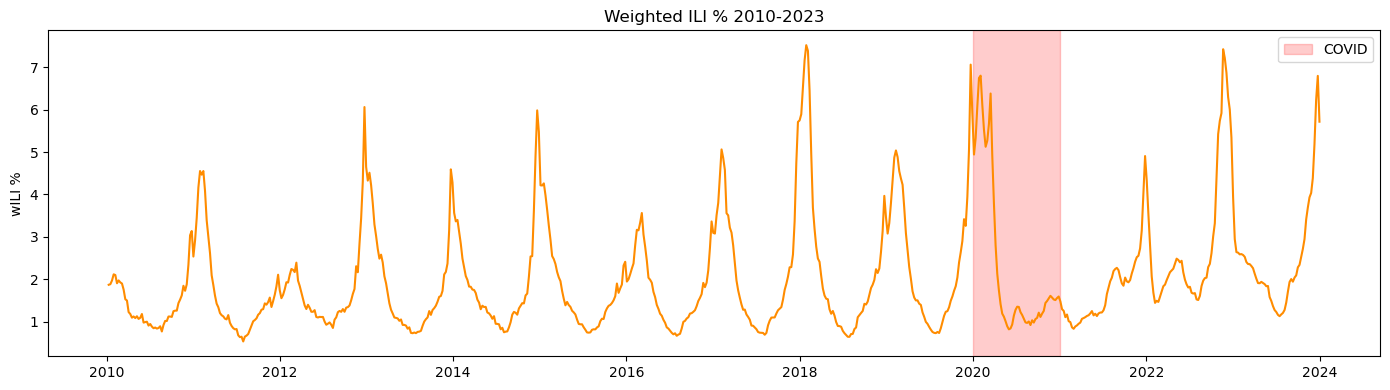

In [5]:
plt.figure(figsize=(14, 4))
plt.plot(master_df.index, master_df['wili'], color='darkorange')
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.title('Weighted ILI % 2010-2023')
plt.ylabel('wILI %')
plt.legend()
plt.tight_layout()
plt.savefig('plot3_ili.png', dpi=150)
plt.show()

What it shows: The CDC's (fluView) weekly measure of what percentage of doctor visits were flu-like illness, over 14 years.
Interpretation: Clear seasonal pattern — flu spikes every winter and drops every summer, like clockwork. COVID disrupted the seasonal pattern in 2020–2021 — wILI dropped to its lowest sustained level in the dataset (~1%) during the shaded window. This drop reflects suppressed flu transmission itself — masking, social distancing, and school closures produced a documented record-low flu season globally — rather than people simply avoiding doctor visits. The pattern recovered afterward: the 2022 winter peak (~7.4%) returns to essentially the same intensity as the pre-COVID high (2018, ~7.5%, the all-time max in this series), rather than remaining permanently suppressed.
Relevance: This is your core health surveillance signal. The seasonal pattern is strong and consistent but the market doesn't react to it — routine flu seasons don't move stocks. That's a key finding. The market only reacted when something broke the pattern.

### Health Signal: Google Trends — Flu Symptoms

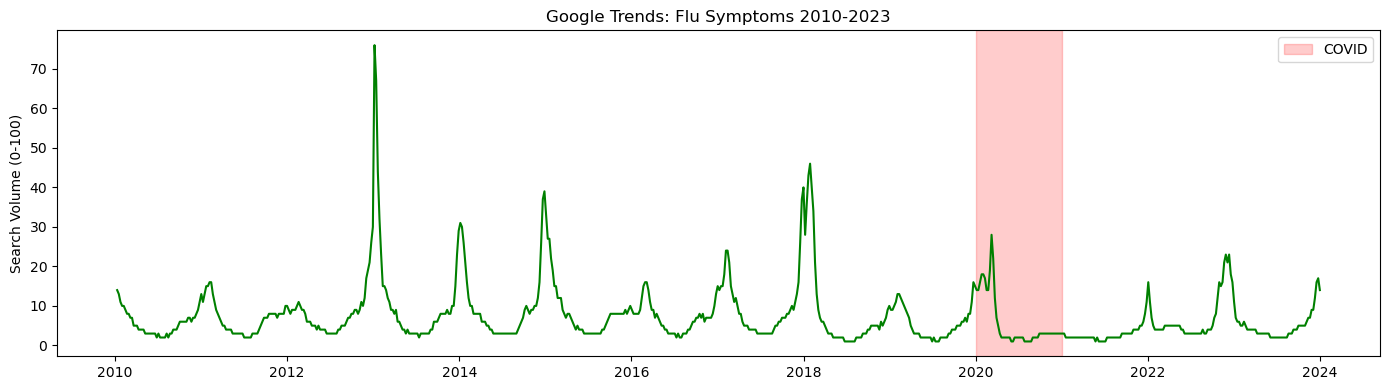

In [6]:
plt.figure(figsize=(14, 4))
plt.plot(master_df.index, master_df['trends_flu_symptoms'], color='green')
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.title('Google Trends: Flu Symptoms 2010-2023')
plt.ylabel('Search Volume (0-100)')
plt.legend()
plt.tight_layout()
plt.savefig('plot4_trends.png', dpi=150)
plt.show()

What it shows: How often Americans searched "flu symptoms" on Google each week.
Interpretation: Also seasonal, also spikes in winter. But the pattern is noisier than FluView, and COVID's peak (~28) is actually smaller than several ordinary flu-season peaks — 2013 (~76), 2014 (~39), and 2018 (~46) all search higher than COVID ever did. COVID is visually distinct mainly because search volume stays elevated and flat through the shaded window rather than dropping off after a single winter peak.
Relevance: Google Trends is a leading indicator — people search before they go to the doctor. If search volume spikes before ILI spikes, that could be a pre-announcement signal. Whether the COVID-era search behavior actually preceded official announcements isn't tested by this chart — that would require comparing search-volume timing against a dated record of COVID announcements, which isn't done in this notebook.

### Overlay: Market Volatility vs ILI

A dual-axis chart placing the target variable (ETF volatility) and the primary health signal (wILI) on the same timeline, making alignment or misalignment during different periods immediately visible.

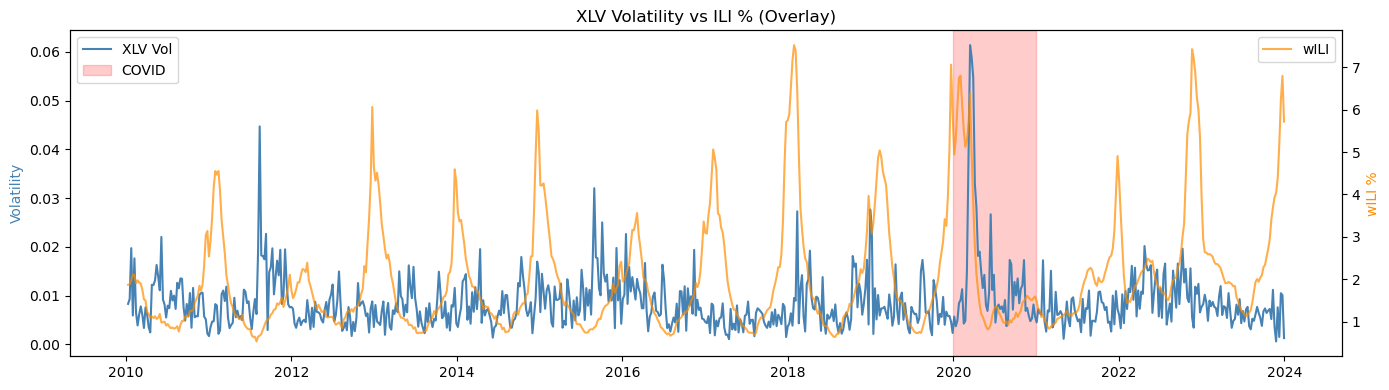

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax2 = ax.twinx()
ax.plot(master_df.index, master_df['XLV_vol'], color='steelblue', label='XLV Vol')
ax2.plot(master_df.index, master_df['wili'], color='darkorange', alpha=0.7, label='wILI')
ax.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
ax.set_title('XLV Volatility vs ILI % (Overlay)')
ax.set_ylabel('Volatility', color='steelblue')
ax2.set_ylabel('wILI %', color='darkorange')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('plot5_overlay.png', dpi=150)
plt.show()

What it shows: XLV volatility (blue, left axis) and weighted ILI (orange, right axis) on the same chart with two y-axes.
Interpretation: In normal flu seasons, ILI spikes every winter but XLV volatility barely moves. During COVID, both spike simultaneously but the volatility spike is far more dramatic and happens faster. The two lines don't track each other consistently â€” they only converge during extreme events.
Relevance: This is the visual proof of your core finding. The relationship between health signals and volatility is not consistent â€” it's conditional on the severity of the health event. This justifies your research question and motivates the predictive model.

## Correlation Analysis

Quantifies the linear relationship between health signals and sector volatility across the full dataset and across subgroups. Pearson correlations are used throughout; because volatility is not normally distributed (confirmed below), these values should be interpreted as directional indicators rather than precise effect sizes.

### Full Period: Health Signals vs Sector Volatility

Correlates each of the four health signals against each of the four ETF volatility columns using the complete 2010-2023 dataset.

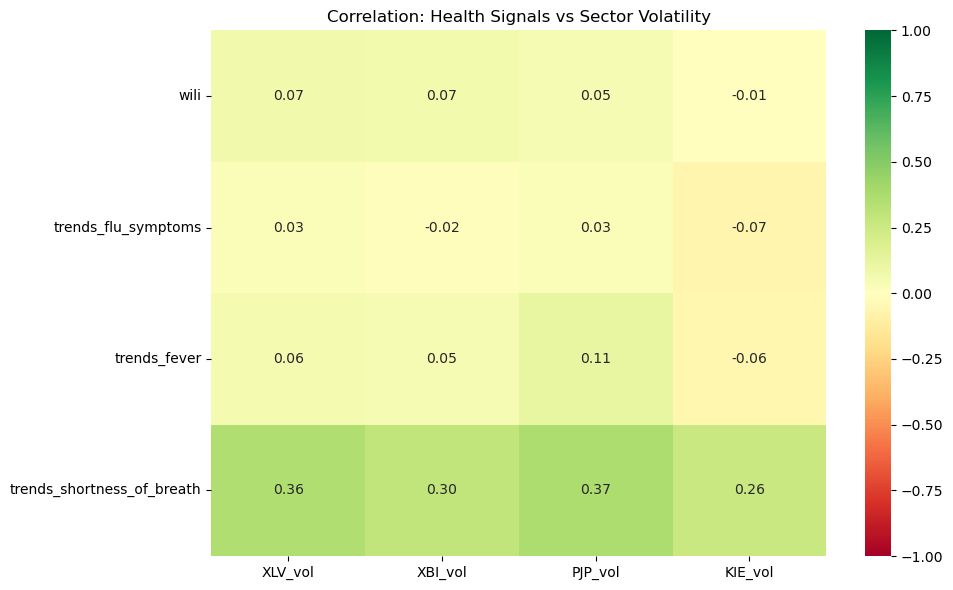

In [8]:
import seaborn as sns

# Correlate health signals against each ETF volatility
health_signals = ['wili', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath']
vol_cols = ['XLV_vol', 'XBI_vol', 'PJP_vol', 'KIE_vol']

corr_matrix = master_df[health_signals + vol_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix.loc[health_signals, vol_cols], 
            annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1)
plt.title('Correlation: Health Signals vs Sector Volatility')
plt.tight_layout()
plt.savefig('plot6_correlation.png', dpi=150)
plt.show()

`trends_shortness_of_breath` shows the strongest correlation with all four volatility measures, driven largely by the COVID period. `wili` shows weaker but consistently positive-to-negligible correlations across all four ETFs (0.07, 0.07, 0.05, −0.01). `trends_flu_symptoms` is weaker still and not consistently signed (0.03, −0.02, 0.03, −0.07) — it does not show the same directional pattern as `wili`. The pre-COVID subset below isolates the baseline relationship outside the COVID shock.

### Pre-COVID Only (2010-2019)

Repeats the correlation analysis on data before January 2020 to test whether any health-market relationship exists outside the pandemic shock.

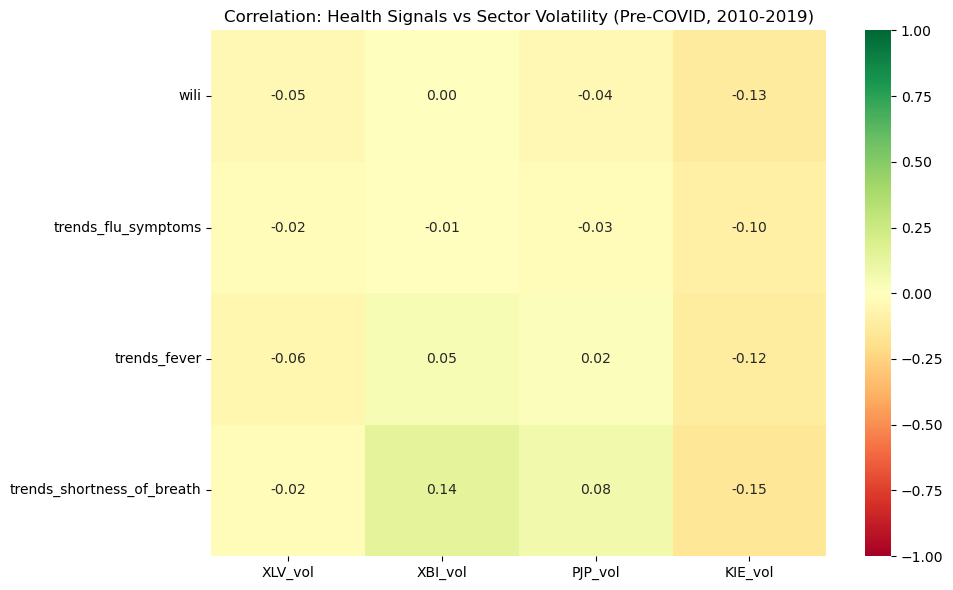

In [9]:
pre_covid = master_df[master_df.index < '2020-01-01']

corr_pre = pre_covid[health_signals + vol_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_pre.loc[health_signals, vol_cols],
            annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1)
plt.title('Correlation: Health Signals vs Sector Volatility (Pre-COVID, 2010-2019)')
plt.tight_layout()
plt.savefig('plot7_correlation_precovid.png', dpi=150)
plt.show()

Pre-COVID correlations are near zero or slightly negative, confirming that routine flu seasons do not meaningfully move health-sector volatility. The full-period correlations are almost entirely driven by the COVID event.

## Statistical Assumption Tests

Before modeling, three key assumptions are tested: normality of the target variable, multicollinearity among health signals, and independence of observations (autocorrelation). Results from these tests directly inform modeling decisions in Phase 2.

### Normality — Shapiro-Wilk Test

Tests whether each ETF weekly volatility series follows a normal distribution. The null hypothesis is normality; p < 0.05 rejects it.

In [10]:
# Normality - Shapiro-Wilk test on volatility columns
from scipy import stats

for col in ['XLV_vol', 'XBI_vol', 'PJP_vol', 'KIE_vol']:
    stat, p = stats.shapiro(master_df[col])
    print(f"{col}: p={p:.4f} â€” {'NOT normal' if p < 0.05 else 'normal'}")

XLV_vol: p=0.0000 â€” NOT normal
XBI_vol: p=0.0000 â€” NOT normal
PJP_vol: p=0.0000 â€” NOT normal
KIE_vol: p=0.0000 â€” NOT normal


All four volatility series strongly reject normality (p = 0.0000). This is expected for financial volatility, which is right-skewed with heavy tails. Non-parametric methods or log-transformed targets should be considered in modeling.

### Multicollinearity — Health Signal Intercorrelations

Checks pairwise correlations among the four health predictors. High inter-predictor correlations can destabilize regression coefficients even when individual correlations with the target are meaningful.

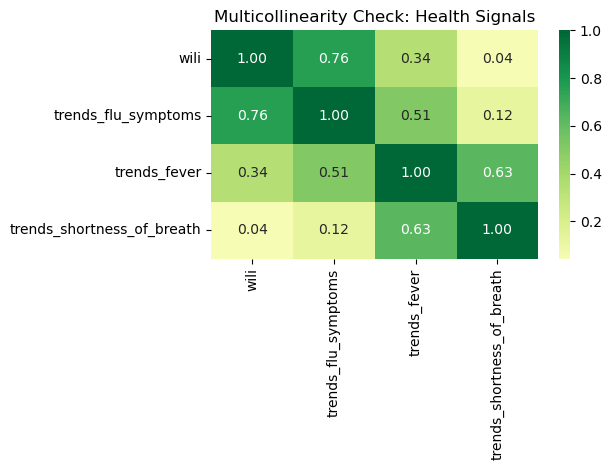

In [11]:
# Multicollinearity - correlation among health signals only
health_corr = master_df[['wili', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath']].corr()
sns.heatmap(health_corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Multicollinearity Check: Health Signals')
plt.tight_layout()
plt.savefig('plot8_multicollinearity.png', dpi=150)
plt.show()

`trends_fever` and `trends_shortness_of_breath` correlate at roughly 0.62. Of the two, only `trends_fever` correlates with `wili` at a moderate level (~0.34); `trends_shortness_of_breath` is close to independent of `wili` (~0.04–0.07, negligible). `trends_shortness_of_breath` is the most distinct signal. Consider dropping or combining highly correlated predictors before fitting a linear model.

### Autocorrelation — Durbin-Watson Test

Tests for serial correlation in the volatility series. Values near 2 indicate independence; values near 0 indicate strong positive autocorrelation.

In [12]:
# Independence - Durbin-Watson test on XLV volatility
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(master_df['XLV_vol'])
print(f"Durbin-Watson: {dw:.4f}")
print("Close to 2 = independent, <2 = positive autocorrelation, >2 = negative")

Durbin-Watson: 0.2769
Close to 2 = independent, <2 = positive autocorrelation, >2 = negative


A Durbin-Watson statistic of 0.2769 indicates strong positive autocorrelation — this week's volatility is strongly predicted by last week's volatility. Any model must account for this temporal dependence, e.g. by including lagged volatility as a feature or using time-series-aware cross-validation.

## Subgroup Correlation Analysis

Beyond the full-period and pre-COVID splits, two additional subgroups test whether the health-market relationship is seasonal or era-specific.

### Flu Season Only (September-December)

Filters to the four months when influenza is most active. If health signals drive volatility even in non-pandemic years, flu-season correlations should be higher than the full-period baseline.

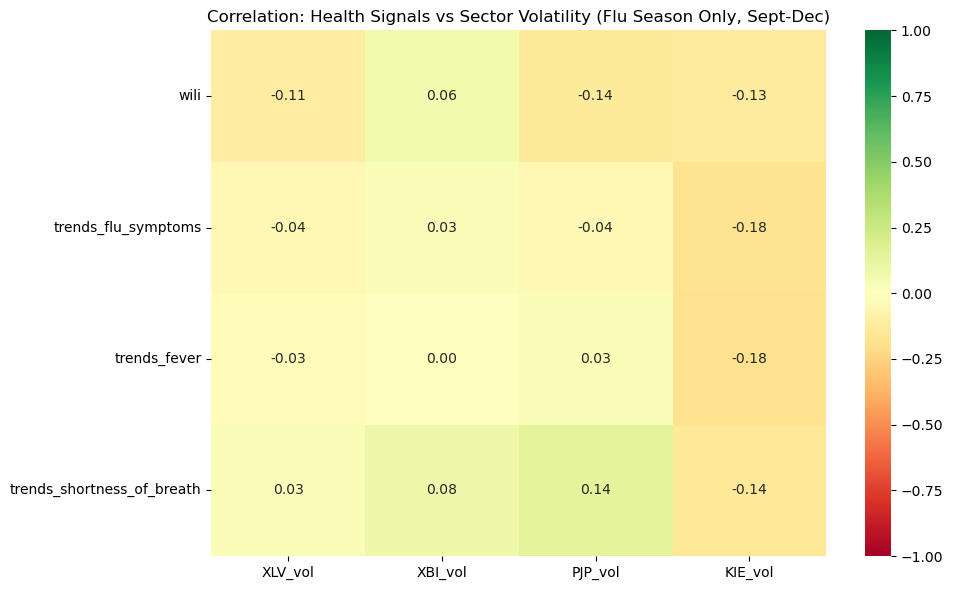

Rows in flu season subset: 244


In [13]:
# Filter to flu season months only (September through December)
flu_season = master_df[master_df.index.month.isin([9, 10, 11, 12])]

health_signals = ['wili', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath']
vol_cols = ['XLV_vol', 'XBI_vol', 'PJP_vol', 'KIE_vol']

corr_flu_season = flu_season[health_signals + vol_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_flu_season.loc[health_signals, vol_cols],
            annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1)
plt.title('Correlation: Health Signals vs Sector Volatility (Flu Season Only, Sept-Dec)')
plt.tight_layout()
plt.savefig('plot8_correlation_fluseason.png', dpi=150)
plt.show()

print(f"Rows in flu season subset: {len(flu_season)}")

Flu-season correlations are not materially higher than the full-period values, reinforcing the finding that seasonal flu alone does not trigger healthcare-sector market volatility — scale and novelty of the health event matter more than seasonality.

### Period Comparison: Pre-COVID / COVID / Post-COVID

Splits the data into three eras and computes a separate correlation heatmap for each, revealing whether the health-market relationship is stable, emergent, or transient.

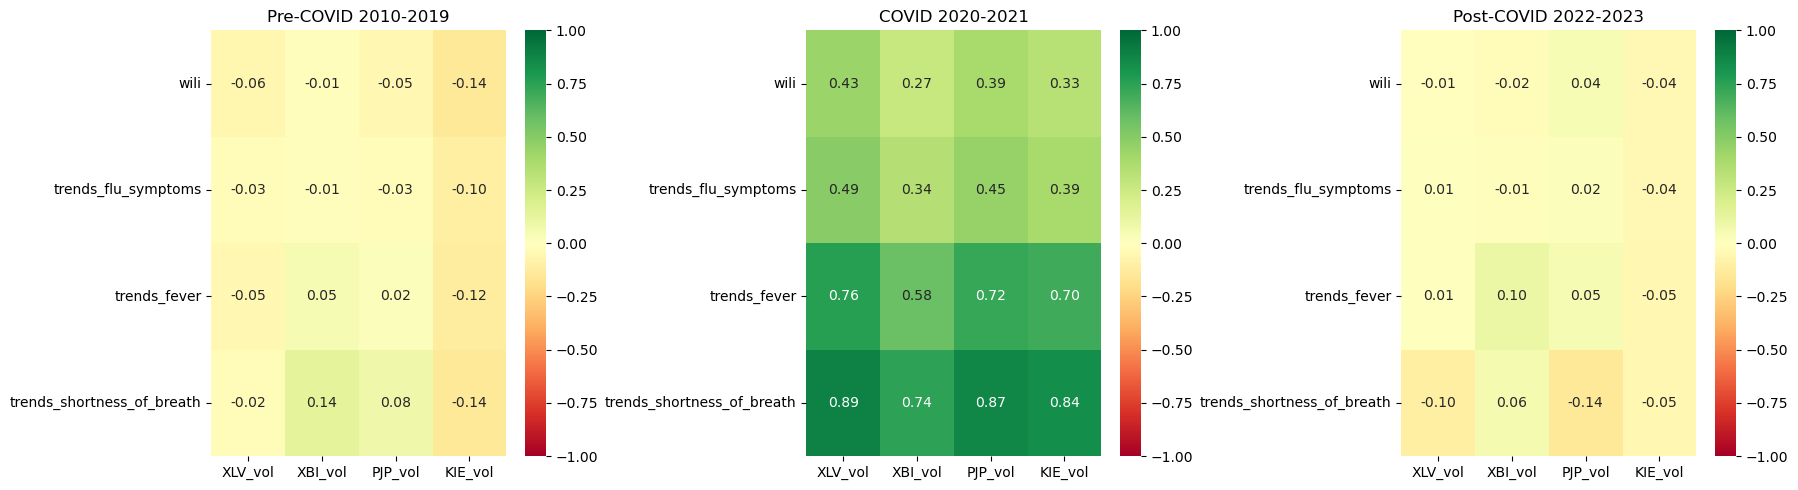

In [14]:
# Three period windows
pre_covid = master_df[master_df.index < '2020-02-01']
covid = master_df[(master_df.index >= '2020-02-01') & (master_df.index < '2021-12-31')]
post_covid = master_df[master_df.index >= '2021-12-31']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
periods = [('Pre-COVID 2010-2019', pre_covid), 
           ('COVID 2020-2021', covid), 
           ('Post-COVID 2022-2023', post_covid)]

for ax, (title, df) in zip(axes, periods):
    corr = df[health_signals + vol_cols].corr().loc[health_signals, vol_cols]
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('plot9_three_periods.png', dpi=150)
plt.show()

Correlations shift dramatically across eras. The COVID window (2020-2021) shows strong positive correlations. Pre-COVID and post-COVID correlations revert toward zero, suggesting the relationship is crisis-specific rather than a persistent structural link.

The COVID window here starts Feb 1, 2020 rather than Jan 1, since markets didn't react until the S&P 500 peaked Feb 19, 2020 and the crash began the following week — including all of January would mix pre-crisis behavior into the "COVID" bucket. Dec 31, 2021 is functionally equivalent to Jan 1, 2022 for weekly data. This differs from the one-year `axvspan` shading (Jan 1, 2020–Jan 1, 2021) used in the time-series plots earlier in this notebook, which exists for a different purpose: those plots shade a simple, visually clean calendar-year reference for spike timing, while this cell needs a structurally-motivated regime boundary for splitting correlation statistics.

## Full Feature Correlation Matrix

Shows pairwise correlations across all 19 features to surface multicollinearity, redundant variables, and spurious time-trend correlations before feature selection.

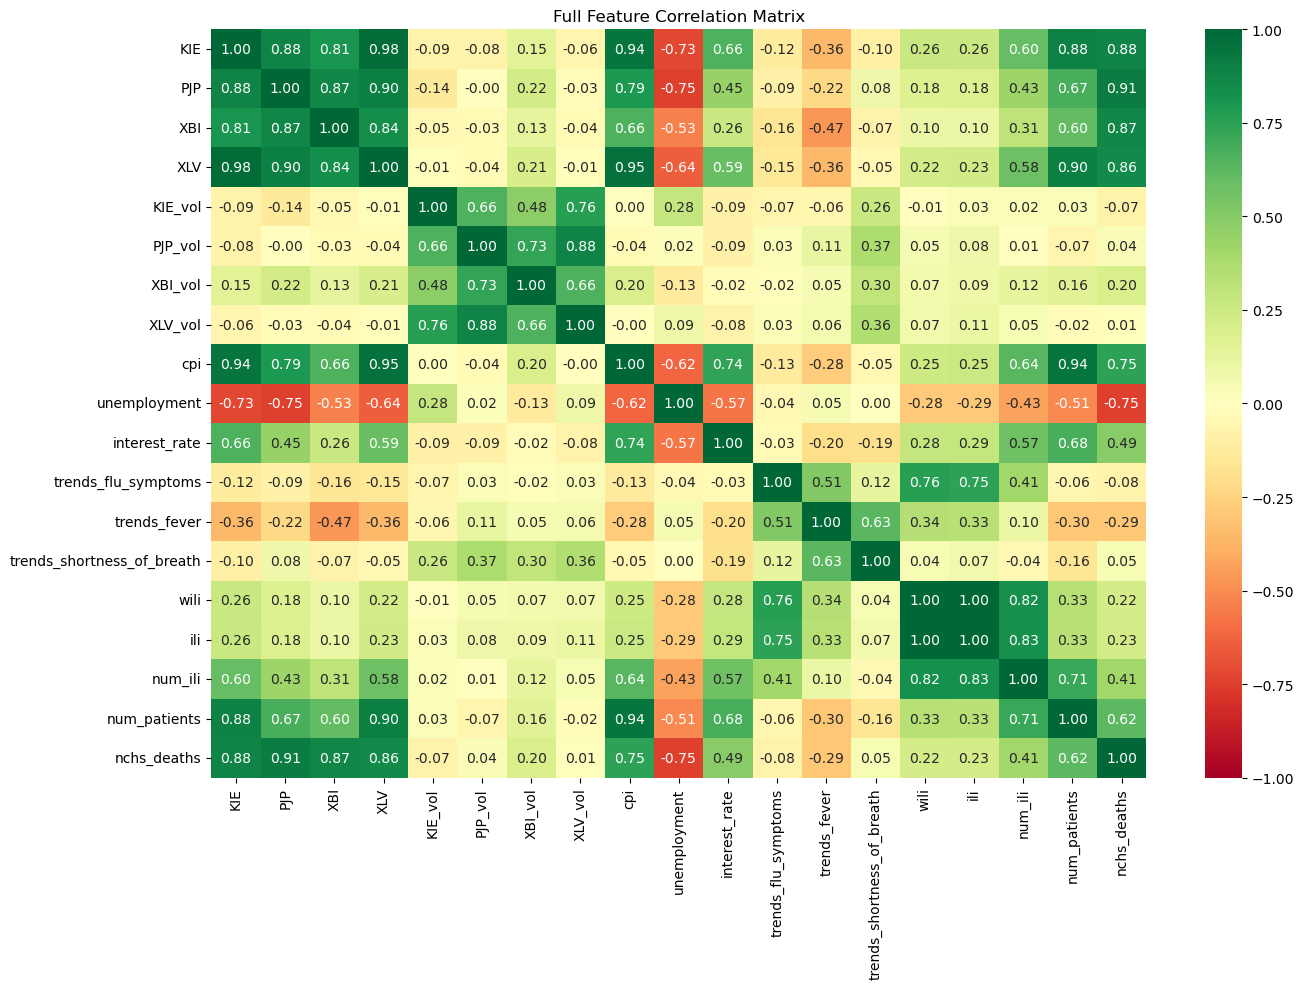

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
sns.heatmap(master_df.corr(), annot=True, fmt='.2f', 
            cmap='RdYlGn', center=0, vmin=-1, vmax=1)
plt.title('Full Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('plot10_full_correlation.png', dpi=150)
plt.show()

**Price columns are near-duplicates.** KIE, PJP, XBI, and XLV correlate at
0.81–0.98 (XLV/KIE = 0.98). They track the same broad market movement and carry
essentially one signal. Drop all four from the feature set — the volatility
columns derived from them are the targets.

**`ili` and `wili` are identical (r = 1.00).** Keep `wili` (weighted, the CDC's
preferred measure); drop `ili`.

**Spurious trend-driven correlations.** `num_patients` correlates 0.94 with CPI,
and `nchs_deaths` correlates 0.88–0.91 with the price columns. Neither is a real
relationship — both series trend upward over time, as do prices and CPI, so the
correlation reflects shared drift rather than any economic link. `num_patients`
adds nothing beyond CPI; `nchs_deaths` is near-constant annual data
forward-filled to weekly, so it carries almost no within-year variance. Drop both.

**Moderate correlation among health signals.** `trends_fever` and
`trends_shortness_of_breath` correlate at 0.61; `trends_flu_symptoms` and `wili`
at 0.76. This is expected — they measure overlapping respiratory illness. The
strongest pair implies a VIF of roughly 2.2, well below the standard threshold
of 5, so all are retained.

**Health signals show near-zero correlation with the volatility targets.**
Across the full period, every health feature sits between −0.08 and +0.38
against the four `*_vol` columns. This is the first indication that the
health–volatility relationship is not present in aggregate, and motivates the
period-split analysis that follows.


## Lag Analysis

Tests whether health signals from 1-4 weeks prior are better predictors of current volatility than contemporaneous signals. A leading indicator relationship would be essential for any forward-looking model.

In [16]:
# Test whether health signals from prior weeks predict this week's volatility
# Lag 1 = last week, Lag 2 = 2 weeks ago, etc.

lag_results = []

for signal in ['wili', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath']:
    for lag in range(1, 5):
        lagged = master_df[signal].shift(lag)
        corr = lagged.corr(master_df['XLV_vol'])
        lag_results.append({'signal': signal, 'lag_weeks': lag, 'correlation': round(corr, 3)})

lag_df = pd.DataFrame(lag_results)
print(lag_df.to_string(index=False))

                    signal  lag_weeks  correlation
                      wili          1        0.090
                      wili          2        0.106
                      wili          3        0.112
                      wili          4        0.124
       trends_flu_symptoms          1        0.052
       trends_flu_symptoms          2        0.073
       trends_flu_symptoms          3        0.070
       trends_flu_symptoms          4        0.070
              trends_fever          1        0.049
              trends_fever          2        0.028
              trends_fever          3        0.004
              trends_fever          4       -0.013
trends_shortness_of_breath          1        0.317
trends_shortness_of_breath          2        0.239
trends_shortness_of_breath          3        0.155
trends_shortness_of_breath          4        0.090


`trends_shortness_of_breath` at lag 1 (r = 0.317) is the strongest predictor found in the dataset — stronger than any contemporaneous correlation. `wili` shows a modest but increasing pattern with longer lags. `trends_fever` loses predictive value beyond lag 1. These results suggest that search behavior around respiratory distress precedes market volatility by approximately one week.

## Rolling Correlation

Computes a 52-week rolling Pearson correlation between `wili` and `XLV_vol`. A time-varying correlation reveals when the health-market relationship is active versus dormant, and whether it persists after the COVID shock.

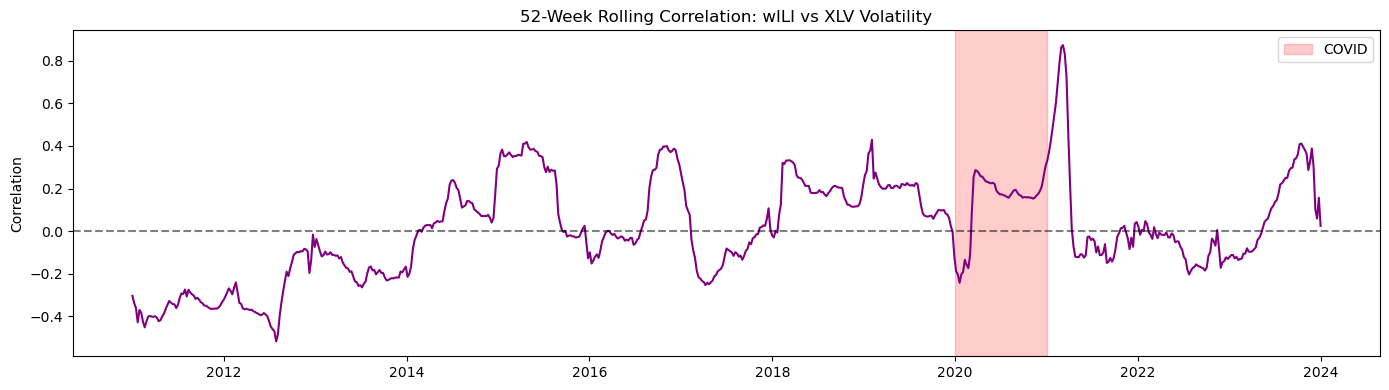

In [17]:
# 52-week rolling correlation between wILI and XLV_vol
# Shows when the relationship turns on and off over time

rolling_corr = master_df['wili'].rolling(52).corr(master_df['XLV_vol'])

plt.figure(figsize=(14, 4))
plt.plot(master_df.index, rolling_corr, color='purple')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.title('52-Week Rolling Correlation: wILI vs XLV Volatility')
plt.ylabel('Correlation')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot11_rolling_correlation.png', dpi=150)
plt.show()

The rolling correlation hovers near zero for most of the pre-COVID decade, spikes sharply during the 2020 COVID onset, then gradually decays back toward baseline. This confirms the health-market relationship is regime-dependent: it activates during genuine health crises and is otherwise absent.

## Volatility Spike Detection

Defines a volatility spike as any week where XLV volatility exceeds 1.5 times its historical mean, then identifies and visualizes all spike weeks.

Mean XLV volatility: 0.0086
Spike threshold (1.5x mean): 0.0128
Total weeks: 730
Spike weeks: 109
Spike rate: 14.9%


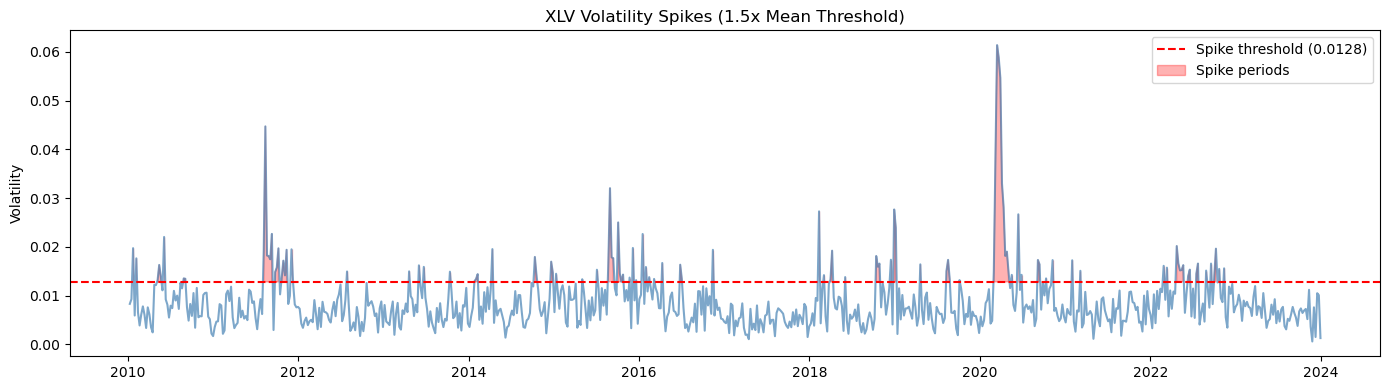

In [18]:
# Define a volatility spike as XLV_vol exceeding 1.5x its historical mean
threshold = master_df['XLV_vol'].mean() * 1.5
spikes = (master_df['XLV_vol'] > threshold).astype(int)

print(f"Mean XLV volatility: {master_df['XLV_vol'].mean():.4f}")
print(f"Spike threshold (1.5x mean): {threshold:.4f}")
print(f"Total weeks: {len(master_df)}")
print(f"Spike weeks: {spikes.sum()}")
print(f"Spike rate: {spikes.mean()*100:.1f}%")

plt.figure(figsize=(14, 4))
plt.plot(master_df.index, master_df['XLV_vol'], color='steelblue', alpha=0.7)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Spike threshold ({threshold:.4f})')
plt.fill_between(master_df.index, threshold, master_df['XLV_vol'],
                 where=master_df['XLV_vol'] > threshold,
                 color='red', alpha=0.3, label='Spike periods')
plt.title('XLV Volatility Spikes (1.5x Mean Threshold)')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot12_volatility_spikes.png', dpi=150)
plt.show()

Spike weeks are concentrated almost entirely in the COVID period. The 1.5x mean threshold cleanly separates COVID-era market stress from normal fluctuation, validating it as a reasonable binary classification target for a predictive model.